<a href="https://colab.research.google.com/github/VoSaiMORDELON/JonInWork/blob/main/Evaluacion_n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de imágenes con una red neuronal MLP

En esta Evaluación Parcial 2 se continúa el trabajo realizado en la EP1, utilizando el modelo MLP baseline como punto de partida para analizar técnicas de regularización.

El overfitting ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, pero no logra generalizar de la misma forma con datos nuevos. Esto se puede observar cuando la accuracy de entrenamiento mejora constantemente, mientras que la validación se estanca o la pérdida de validación aumenta.

El objetivo de esta evaluación es aplicar y comparar técnicas como L2 Regularization, Dropout, Batch Normalization y Early Stopping, con el fin de analizar su impacto en el rendimiento, la estabilidad y la generalización del modelo.

#### Importación de librerías

En esta sección se importan las librerías necesarias para el desarrollo del notebook.  
Se utiliza NumPy para el manejo de datos numéricos, Matplotlib para la generación de gráficos, Pandas para organizar los resultados en tablas, TensorFlow/Keras para construir y entrenar los modelos de Deep Learning, y Scikit-learn para calcular las métricas de evaluación como accuracy, precision, recall y F1-score.

In [ ]:
import numpy as np
import gzip
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

#### Configuración de reproducibilidad

Se configuran semillas aleatorias para que los experimentos sean más reproducibles y los resultados puedan mantenerse lo más consistentes posible al volver a ejecutar el notebook.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

## Definición de funciones para cargar el dataset

El dataset Fashion-MNIST fue entregado en archivos comprimidos `.gz`, por lo que fue necesario definir funciones para leer las imágenes y las etiquetas.

Las imágenes se cargan como matrices de 28x28 píxeles en escala de grises, mientras que las etiquetas representan la clase de cada prenda.

**Nota:** Para leer correctamente los archivos se utilizó `np.frombuffer`, omitiendo los metadatos iniciales con `offset` (16 bytes en imágenes y 8 bytes en etiquetas).

In [ ]:
def load_images(path):
    with gzip.open(path, 'rb') as f:
        images = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
        images = images.reshape(-1, 28, 28)
    return images

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return labels

### Carga de datos de entrenamiento y prueba

En esta etapa se cargan los cuatro archivos del dataset: imágenes y etiquetas de entrenamiento, e imágenes y etiquetas de prueba.

Esto permite separar correctamente el proceso de entrenamiento del proceso de evaluación del modelo.

In [ ]:
X_train = load_images('/content/train-images-idx3-ubyte.gz')
y_train = load_labels('/content/train-labels-idx1-ubyte.gz')

X_test = load_images('/content/t10k-images-idx3-ubyte.gz')
y_test = load_labels('/content/t10k-labels-idx1-ubyte.gz')

### Verificación de dimensiones

Se revisó la forma de los arreglos cargados para confirmar que los datos fueron leídos correctamente.

El conjunto de entrenamiento contiene 60.000 imágenes y el conjunto de prueba 10.000 imágenes. Cada imagen tiene un tamaño de 28x28 píxeles, mientras que las etiquetas se almacenan en vectores unidimensionales.

In [ ]:
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test: (10000, 28, 28)
Forma de y_test: (10000,)


### Visualización de ejemplos del dataset

Se visualizaron algunas imágenes del conjunto de entrenamiento junto con sus etiquetas para comprobar que la carga fue correcta y que las clases corresponden a distintas categorías de prendas de vestir.

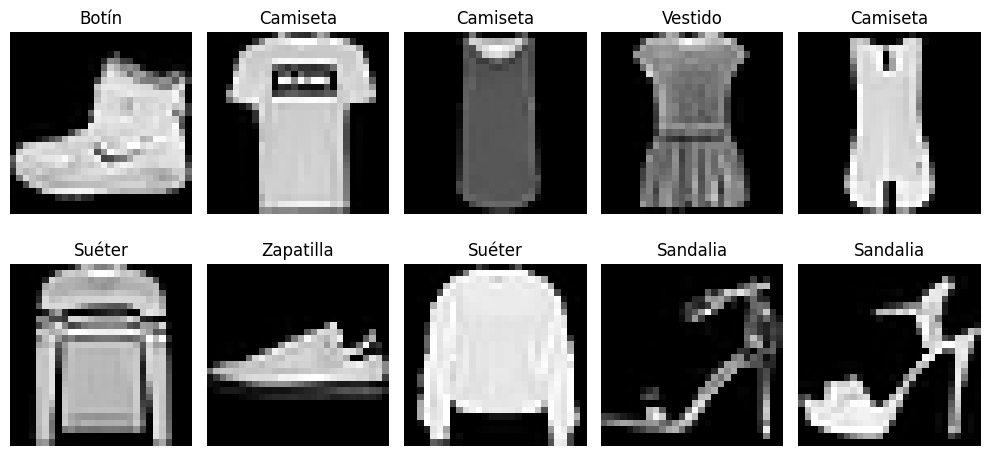

In [ ]:
class_names = [
    "Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Preprocesamiento de los datos

Antes de entrenar la red neuronal, fue necesario preparar los datos.  
Primero, se normalizaron los valores de los píxeles al rango [0,1]. Luego, cada imagen de 28x28 píxeles fue transformada en un vector de 784 características, ya que una red MLP recibe vectores de entrada y no imágenes bidimensionales.

In [ ]:
# Normalización de los píxeles
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Aplanar las imágenes: de 28x28 a 784
X_train = X_train.reshape(60000, 28 * 28)
X_test = X_test.reshape(10000, 28 * 28)

print("Nueva forma de X_train:", X_train.shape)
print("Nueva forma de X_test:", X_test.shape)
print("Valor mínimo en X_train:", X_train.min())
print("Valor máximo en X_train:", X_train.max())

Nueva forma de X_train: (60000, 784)
Nueva forma de X_test: (10000, 784)
Valor mínimo en X_train: 0.0
Valor máximo en X_train: 1.0


Se normalizaron los valores de los píxeles al rango entre 0 y 1, lo que favorece la estabilidad del entrenamiento y evita que valores demasiado altos afecten el aprendizaje del modelo. Posteriormente, cada imagen de 28x28 píxeles fue transformada en un vector de 784 características, ya que una red MLP recibe vectores de entrada y no imágenes bidimensionales.

## Construcción y definición del modelo MLP

Una vez finalizado el preprocesamiento, los datos quedaron listos para ser utilizados como entrada en una red neuronal multicapa (MLP).  

Cada imagen fue representada como un vector de 784 características, lo que permite usarla posteriormente en la etapa de definición y entrenamiento del modelo.

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Justificación inicial de la arquitectura

Se eligió una arquitectura MLP simple como punto de partida, ya que permite aplicar de manera directa los fundamentos revisados en la asignatura, como perceptrón multicapa, redes feed forward, funciones de activación y clasificación multiclase.

La función ReLU se utilizó en las capas ocultas debido a su buen desempeño durante el entrenamiento, mientras que Softmax se utilizó en la capa de salida porque permite obtener probabilidades para cada una de las 10 clases del dataset.

## Compilación del modelo

Una vez definida la arquitectura, se procedió a compilar el modelo. En esta etapa se seleccionó el optimizador, la función de pérdida y la métrica principal de evaluación que se utilizarán durante el entrenamiento.

Se utilizó el optimizador Adam por su buen desempeño en problemas de clasificación, la función de pérdida `sparse_categorical_crossentropy` debido a que las etiquetas están representadas como números enteros, y accuracy como métrica inicial para monitorear el aprendizaje del modelo.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Esta configuración permite que el modelo aprenda minimizando el error de clasificación y monitoreando su porcentaje de aciertos durante el entrenamiento.

## Entrenamiento del modelo

Una vez compilado el modelo, se realizó el proceso de entrenamiento utilizando el conjunto de datos de entrenamiento.

En esta etapa, la red neuronal ajusta sus pesos internos a partir de los ejemplos entregados, con el objetivo de minimizar la función de pérdida y mejorar su capacidad de clasificación.

Para esta primera configuración se utilizaron 10 épocas, un batch size de 32 y un 20% de los datos de entrenamiento como conjunto de validación, con el fin de monitorear el desempeño del modelo durante el aprendizaje.

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8142 - loss: 0.5238 - val_accuracy: 0.8510 - val_loss: 0.4134
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8625 - loss: 0.3821 - val_accuracy: 0.8629 - val_loss: 0.3711
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8743 - loss: 0.3411 - val_accuracy: 0.8673 - val_loss: 0.3587
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8839 - loss: 0.3155 - val_accuracy: 0.8732 - val_loss: 0.3550
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8906 - loss: 0.2969 - val_accuracy: 0.8740 - val_loss: 0.3513
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8958 - loss: 0.2790 - val_accuracy: 0.8792 - val_loss: 0.3432
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9003 - loss: 0.2646 - val_accuracy: 0.8794 - val_loss: 0.3425
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9049 - loss: 0.2525 - 

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


### Análisis del entrenamiento

Durante el entrenamiento, el modelo mostró una mejora progresiva en el conjunto de entrenamiento, aumentando su accuracy desde 0.8178 hasta un valor cercano a 0.91 y reduciendo la pérdida desde 0.5144, lo que indica que logró aprender patrones relevantes del dataset.

En el conjunto de validación, la accuracy alcanzó valores cercanos a 0.89, con su mejor resultado de 0.8859 en la época 8. Esto sugiere que el modelo fue capaz de generalizar adecuadamente a datos no vistos.

Sin embargo, en las últimas épocas, las mejoras en validación fueron menores y presentaron ligeras fluctuaciones. Esto puede deberse a que el modelo ya aprendió gran parte de los patrones presentes en los datos, por lo que nuevas iteraciones no generaron mejoras significativas. Además, la cercanía entre los resultados de entrenamiento y validación indica que no se observa un sobreajuste importante.

## Visualización del entrenamiento

Para analizar el comportamiento del modelo durante el proceso de aprendizaje, se graficaron la accuracy y la función de pérdida tanto en entrenamiento como en validación.

Esto permite observar si el modelo mejora con las épocas y detectar posibles señales de sobreajuste o estancamiento.

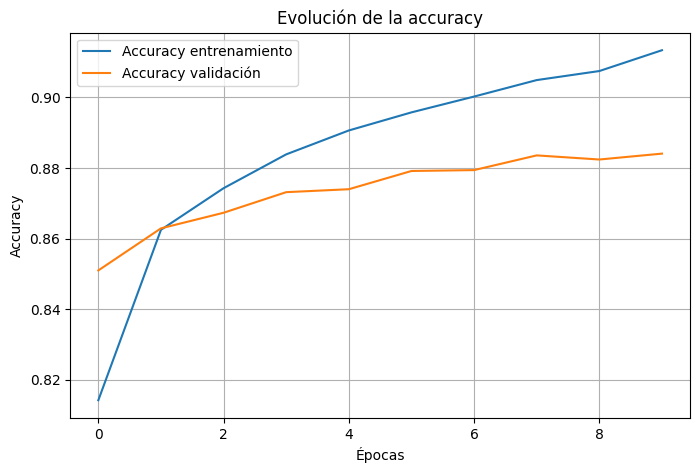

In [ ]:

# Gráfico de accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')
plt.title('Evolución de la accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra que el modelo aprende progresivamente, ya que la accuracy de entrenamiento aumenta de forma constante. La accuracy de validación también mejora, pero se estabiliza en las últimas épocas, lo que sugiere que el modelo alcanza un punto donde deja de generalizar mejor.

La pequeña diferencia entre ambas curvas indica un leve overfitting, aunque no es significativo, por lo que el modelo presenta un buen desempeño general.

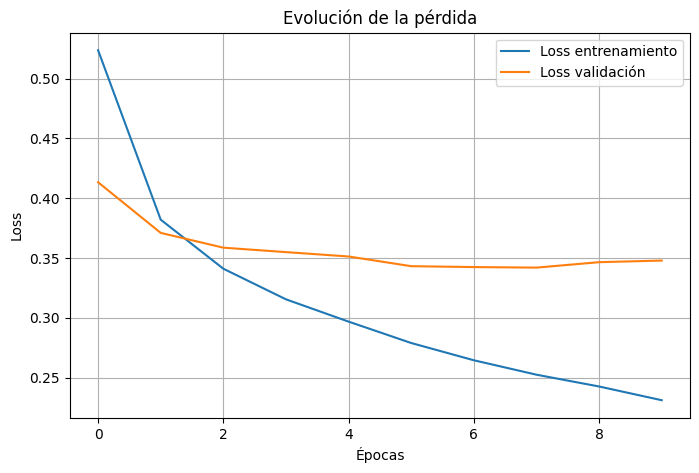

In [ ]:
# Gráfico de loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra que la pérdida de entrenamiento disminuye constantemente, lo que indica un buen aprendizaje del modelo. La pérdida de validación también baja al inicio, pero luego se estabiliza y presenta pequeñas variaciones.

La diferencia entre ambas curvas sugiere un leve overfitting, aunque no es significativo, por lo que el modelo mantiene un buen equilibrio entre ajuste y generalización.

### Interpretación de los gráficos de entrenamiento

En los gráficos se ve que el modelo fue aprendiendo de forma progresiva, porque la accuracy sube y la pérdida baja tanto en entrenamiento como en validación. En validación las mejoras son más claras al inicio y después se estabilizan, lo que sugiere que el modelo ya estaba cerca de su mejor rendimiento. Además, como la diferencia entre ambas curvas no es muy grande, no se observa un sobreajuste importante.”

## Evaluación del modelo en el conjunto de prueba

Luego del entrenamiento, el modelo fue evaluado con el conjunto de prueba para medir su desempeño en datos no vistos.

### Evaluación general en test

Primero se evaluó el modelo sobre el conjunto de prueba para obtener una medida general de pérdida y accuracy.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Loss en test:", test_loss)
print("Accuracy en test:", test_accuracy)

Loss en test: 0.37430739402770996
Accuracy en test: 0.8741000294685364


El modelo obtuvo un accuracy cercano a 0.88 en el conjunto de test, lo que indica un buen nivel de generalización. Además, la pérdida se mantiene en valores adecuados, confirmando un desempeño estable en datos no vistos.

### Generación de predicciones

Se generaron las predicciones del modelo y se seleccionó la clase con mayor probabilidad para cada imagen.

In [ ]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Los resultados muestran un desempeño general adecuado y métricas consistentes en el conjunto de prueba.

### Cálculo de métricas

Con las predicciones obtenidas, se calcularon accuracy, precision, recall y F1-score.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8741
Precision: 0.875258718734312
Recall: 0.8741
F1-score: 0.8738860552598889


Estas métricas son importantes porque permiten evaluar el modelo de forma más completa. La accuracy muestra el desempeño general, mientras que precision, recall y F1-score ayudan a analizar con mayor detalle la calidad de la clasificación.

### Cuadro resumen de métricas

A continuación, se presenta un cuadro resumen con los valores obtenidos para cada métrica.

In [ ]:
metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Valor': [accuracy, precision, recall, f1]
})

metricas

,Métrica,Valor
0,Accuracy,0.874100
1,Precision,0.875259
2,Recall,0.874100
3,F1-score,0.873886


Se observa que las métricas presentan valores muy similares entre sí, lo que indica un desempeño equilibrado del modelo en el conjunto de prueba. Además, la precision es levemente superior, lo que sugiere una buena capacidad para clasificar correctamente las clases predichas.

### Reporte de clasificación por clase

Además de las métricas globales, se generó un reporte de clasificación para analizar el desempeño del modelo en cada clase del dataset.

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Camiseta       0.85      0.82      0.84      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.76      0.81      0.78      1000
     Vestido       0.89      0.86      0.88      1000
      Abrigo       0.78      0.80      0.79      1000
    Sandalia       0.98      0.94      0.96      1000
      Camisa       0.72      0.67      0.69      1000
   Zapatilla       0.88      0.99      0.93      1000
       Bolso       0.93      0.98      0.95      1000
       Botín       0.98      0.90      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



#### Resultados de evaluación del modelo

El modelo baseline fue evaluado con el conjunto de prueba, obteniendo un accuracy de 0.8741, una precision de 0.8753, un recall de 0.8741 y un F1-score de 0.8739. En general, estos resultados muestran un buen desempeño inicial del modelo y sirven como referencia para comparar las técnicas de regularización aplicadas en la EP2.

Por clase, las mejores métricas se observaron en Pantalón, Sandalia, Zapatilla, Bolso y Botín, lo que sugiere que el modelo reconoce mejor prendas visualmente más diferenciables.

En cambio, clases como Camisa, Abrigo y Suéter presentaron un desempeño inferior, probablemente debido a la similitud visual entre estas categorías. Esto muestra que, aunque el modelo generaliza adecuadamente, algunas clases siguen siendo más difíciles de separar para una red MLP simple.

## Técnicas de Regularización

### Análisis inicial del modelo baseline

El modelo baseline corresponde al MLP desarrollado en la Evaluación 1 y será utilizado como referencia para comparar el impacto de distintas técnicas de regularización.

A partir de los gráficos de entrenamiento y validación, se observa una leve diferencia entre ambas curvas, lo que podría indicar un inicio de sobreajuste. Debido a esto, se implementarán distintas técnicas de regularización con el objetivo de mejorar la capacidad de generalización del modelo y analizar su efecto en las métricas finales.

#### Definición de arquitectura con regularización L2 (λ = 0.001)

Se implementa una nueva versión del modelo MLP incorporando regularización L2 en las capas ocultas. Esta técnica agrega una penalización sobre los pesos grandes de la red neuronal, ayudando a reducir el sobreajuste y favoreciendo una mejor generalización.

In [ ]:
model_l2_001 = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

El modelo se compila utilizando el optimizador Adam y la función de pérdida Sparse Categorical Crossentropy, manteniendo la misma configuración del baseline para comparar únicamente el impacto de la regularización L2.

In [ ]:
model_l2_001.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con L2

El modelo se entrena durante 10 épocas utilizando un batch size de 32 y un 20% de los datos para validación. Esto permitirá analizar el comportamiento de las curvas de entrenamiento y validación al aplicar regularización L2.

In [ ]:
history_l2_001 = model_l2_001.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8119 - loss: 0.7160 - val_accuracy: 0.8451 - val_loss: 0.5786
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8483 - loss: 0.5453 - val_accuracy: 0.8508 - val_loss: 0.5313
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8558 - loss: 0.5044 - val_accuracy: 0.8569 - val_loss: 0.4979
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8602 - loss: 0.4803 - val_accuracy: 0.8612 - val_loss: 0.4826
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8646 - loss: 0.4639 - val_accuracy: 0.8617 - val_loss: 0.4741
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8675 - loss: 0.4513 - val_accuracy: 0.8627 - val_loss: 0.4745
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8694 - loss: 0.4424 - val_accuracy: 0.8688 - val_loss: 0.4493
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8716 - loss: 0.4316 -

#### Evaluación del modelo regularizado

Se evalúa el modelo utilizando el conjunto de prueba para obtener la pérdida y accuracy general después de aplicar regularización L2.

In [ ]:
test_loss_l2_001, test_accuracy_l2_001 = model_l2_001.evaluate(X_test, y_test)

print("Loss L2 0.001:", test_loss_l2_001)
print("Accuracy L2 0.001:", test_accuracy_l2_001)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8587 - loss: 0.4641
Loss L2 0.001: 0.46413975954055786
Accuracy L2 0.001: 0.8586999773979187


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan métricas como precision, recall y F1-score para obtener una evaluación más completa del desempeño del modelo regularizado.

In [ ]:
y_prob_l2_001 = model_l2_001.predict(X_test)
y_pred_l2_001 = np.argmax(y_prob_l2_001, axis=1)

accuracy_l2_001 = accuracy_score(y_test, y_pred_l2_001)
precision_l2_001 = precision_score(y_test, y_pred_l2_001, average='weighted')
recall_l2_001 = recall_score(y_test, y_pred_l2_001, average='weighted')
f1_l2_001 = f1_score(y_test, y_pred_l2_001, average='weighted')

print("Accuracy:", accuracy_l2_001)
print("Precision:", precision_l2_001)
print("Recall:", recall_l2_001)
print("F1-score:", f1_l2_001)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8587
Precision: 0.8646395930969755
Recall: 0.8587
F1-score: 0.8590889066587611


#### Evolución de la accuracy

El siguiente gráfico muestra cómo evoluciona la accuracy tanto en entrenamiento como en validación a lo largo de las épocas.

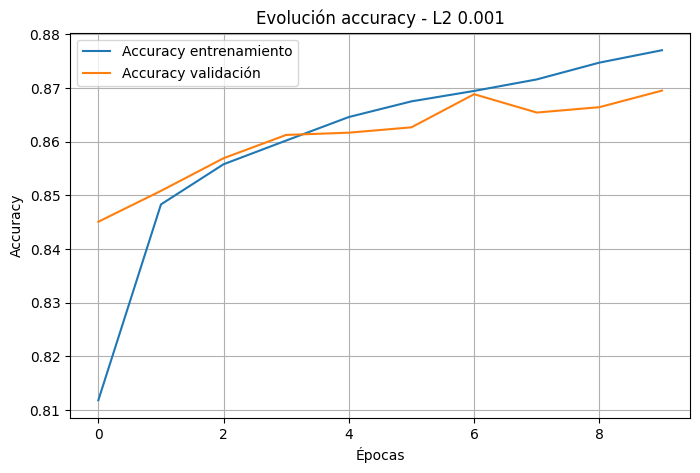

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_001.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_l2_001.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - L2 0.001')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

El siguiente gráfico permite observar cómo evoluciona la pérdida de entrenamiento y validación al aplicar regularización L2 con λ = 0.001.

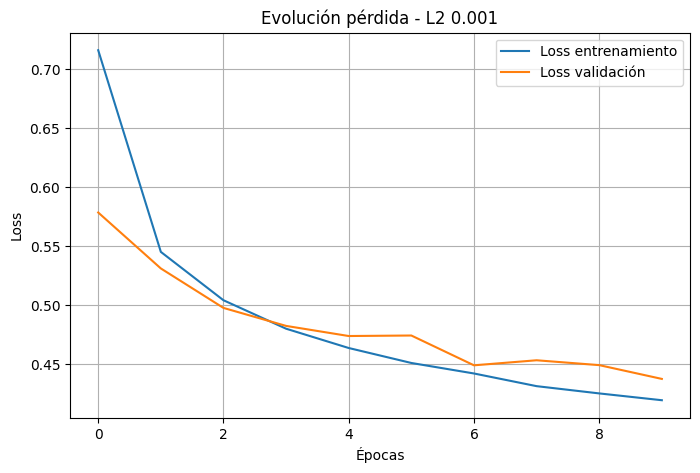

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_001.history['loss'], label='Loss entrenamiento')
plt.plot(history_l2_001.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - L2 0.001')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados L2 (λ = 0.001)

El modelo con L2 λ = 0.001 obtuvo un accuracy de 0.8587 y un F1-score de 0.8591, resultados inferiores al modelo baseline. Esto indica que, aunque la regularización permitió controlar el aprendizaje, no logró mejorar el rendimiento final del modelo.

En el gráfico de accuracy se observa que tanto entrenamiento como validación aumentan de forma progresiva y se mantienen relativamente cercanos, lo que muestra un comportamiento estable. Además, en el gráfico de pérdida se aprecia que tanto la pérdida de entrenamiento como la de validación disminuyen durante las épocas, lo que indica que el modelo sí aprendió correctamente.

Sin embargo, al comparar con el baseline, el rendimiento general fue menor. Esto puede deberse a que L2 penaliza los pesos grandes de la red, evitando que el modelo se ajuste demasiado a los datos de entrenamiento, pero en este caso también pudo limitar su capacidad para aprender patrones más específicos del dataset.

Por lo tanto, L2 con λ = 0.001 ayudó a estabilizar el entrenamiento, pero no fue la mejor configuración en términos de accuracy y F1-score.

### Regularización L2 con λ = 0.01

En esta segunda prueba se aumenta el valor de lambda a 0.01 para analizar el efecto de una regularización más fuerte.  
La idea es comparar si una penalización mayor sobre los pesos ayuda a reducir el sobreajuste o si afecta demasiado la capacidad de aprendizaje del modelo.

### Definición del modelo con L2 (λ = 0.01)

Se mantiene la misma arquitectura del modelo baseline, pero se agrega regularización L2 en las capas ocultas.  
En este caso se utiliza λ = 0.01, un valor mayor que la prueba anterior, por lo que la penalización sobre los pesos será más fuerte.

In [ ]:
model_l2_01 = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ),

    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ),

    layers.Dense(10, activation='softmax')
])


### Compilación del modelo

El modelo se compila utilizando la misma configuración del baseline: optimizador Adam, función de pérdida Sparse Categorical Crossentropy y accuracy como métrica principal.  
Esto permite que el único cambio relevante sea el valor de la regularización L2.


In [ ]:
model_l2_01.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con L2 (λ = 0.01)

El modelo se entrena durante 10 épocas con batch size 32 y un 20% de validación.  
Con esto se busca observar cómo afecta una regularización más fuerte al aprendizaje del modelo durante el entrenamiento.

In [ ]:
history_l2_01 = model_l2_01.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7816 - loss: 1.0791 - val_accuracy: 0.7894 - val_loss: 0.7812
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8082 - loss: 0.7249 - val_accuracy: 0.8090 - val_loss: 0.7010
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8165 - loss: 0.6735 - val_accuracy: 0.8137 - val_loss: 0.6673
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8228 - loss: 0.6411 - val_accuracy: 0.8235 - val_loss: 0.6365
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8263 - loss: 0.6202 - val_accuracy: 0.8294 - val_loss: 0.6095
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8309 - loss: 0.6033 - val_accuracy: 0.8306 - val_loss: 0.6039
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8324 - loss: 0.5902 - val_accuracy: 0.8344 - val_loss: 0.5758
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8344 - loss: 0.5792 - 

#### Evaluación general del modelo

Se evalúa el modelo sobre el conjunto de prueba para obtener la pérdida y accuracy general.  
Estos resultados permitirán comparar el rendimiento de L2 con λ = 0.01 frente al baseline y frente a L2 con λ = 0.001.

In [ ]:
test_loss_l2_01, test_accuracy_l2_01 = model_l2_01.evaluate(X_test, y_test)

print("Loss L2 0.01:", test_loss_l2_01)
print("Accuracy L2 0.01:", test_accuracy_l2_01)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8291 - loss: 0.5796
Loss L2 0.01: 0.5795535445213318
Accuracy L2 0.01: 0.8291000127792358


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan precision, recall y F1-score para obtener una visión más completa del desempeño del modelo.  
Estas métricas serán utilizadas posteriormente en la tabla comparativa final.

In [ ]:
y_prob_l2_01 = model_l2_01.predict(X_test)
y_pred_l2_01 = np.argmax(y_prob_l2_01, axis=1)

accuracy_l2_01 = accuracy_score(y_test, y_pred_l2_01)
precision_l2_01 = precision_score(y_test, y_pred_l2_01, average='weighted')
recall_l2_01 = recall_score(y_test, y_pred_l2_01, average='weighted')
f1_l2_01 = f1_score(y_test, y_pred_l2_01, average='weighted')

print("Accuracy:", accuracy_l2_01)
print("Precision:", precision_l2_01)
print("Recall:", recall_l2_01)
print("F1-score:", f1_l2_01)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8291
Precision: 0.8341775451825665
Recall: 0.8291
F1-score: 0.8288477023832999


#### Evolución de la accuracy

Este gráfico muestra cómo cambia la accuracy de entrenamiento y validación a lo largo de las épocas.  
Permite observar si el modelo aprende correctamente y si existe diferencia entre entrenamiento y validación.

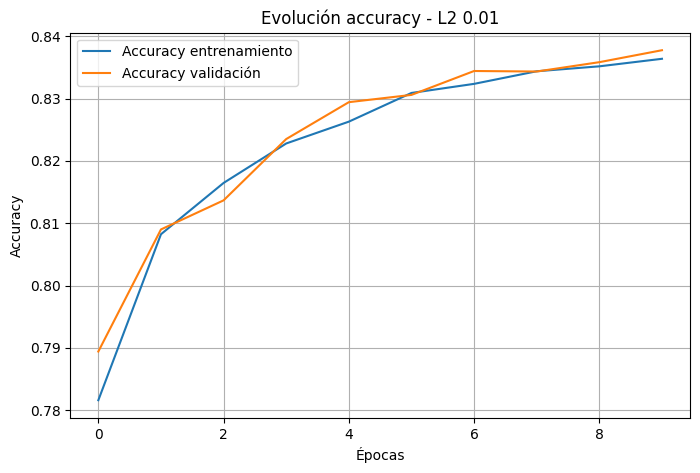

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_01.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_l2_01.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - L2 0.01')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite analizar el comportamiento de la pérdida durante el entrenamiento.  
Es útil para identificar si la regularización ayuda a estabilizar el modelo o si afecta negativamente su aprendizaje.

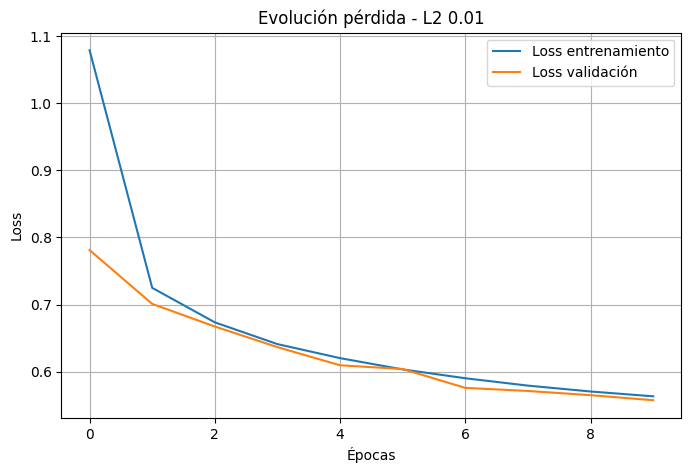

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_01.history['loss'], label='Loss entrenamiento')
plt.plot(history_l2_01.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - L2 0.01')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados L2 (λ = 0.01)

El modelo con L2 y λ = 0.01 obtuvo un accuracy de 0.8291 y un F1-score de 0.8288, siendo el rendimiento más bajo entre los experimentos realizados.

Esto muestra que una regularización más fuerte puede reducir el sobreajuste, pero también puede limitar demasiado la capacidad de aprendizaje del modelo. En este caso, la penalización aplicada a los pesos fue excesiva, por lo que el modelo perdió capacidad para aprender patrones relevantes del dataset.

En conclusión, λ = 0.01 no fue una configuración conveniente, ya que redujo considerablemente el desempeño en comparación con el baseline y con L2 λ = 0.001.

## Regularización con Dropout

Dropout es una técnica de regularización que desactiva aleatoriamente una parte de las neuronas durante el entrenamiento.  
Esto ayuda a que el modelo no dependa demasiado de neuronas específicas y pueda generalizar mejor frente a datos nuevos.

En esta sección se probarán distintas tasas de Dropout para analizar su impacto en el rendimiento del modelo.

### Definición del modelo con Dropout 0.2

Se mantiene la arquitectura base del MLP, pero se agregan capas Dropout después de las capas densas ocultas.  
En esta primera prueba se utiliza una tasa de 0.2, lo que significa que durante el entrenamiento se desactiva aleatoriamente un 20% de las neuronas.

In [ ]:
model_dropout_02 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

El modelo se compila con la misma configuración del baseline para que la comparación sea controlada.  
De esta forma, el cambio principal corresponde a la incorporación de Dropout.

In [ ]:
model_dropout_02.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con Dropout 0.2

El modelo se entrena durante 10 épocas, con batch size 32 y validation_split de 0.2.  
Esto permitirá observar si Dropout mejora la estabilidad del entrenamiento y reduce diferencias entre entrenamiento y validación.

In [ ]:
history_dropout_02 = model_dropout_02.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7767 - loss: 0.6137 - val_accuracy: 0.8461 - val_loss: 0.4209
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8397 - loss: 0.4420 - val_accuracy: 0.8621 - val_loss: 0.3826
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8559 - loss: 0.3995 - val_accuracy: 0.8687 - val_loss: 0.3709
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8623 - loss: 0.3758 - val_accuracy: 0.8696 - val_loss: 0.3630
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8678 - loss: 0.3601 - val_accuracy: 0.8740 - val_loss: 0.3506
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8726 - loss: 0.3467 - val_accuracy: 0.8782 - val_loss: 0.3430
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8765 - loss: 0.3350 - val_accuracy: 0.8802 - val_loss: 0.3382
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8796 - loss: 0.3253 - 

#### Evaluación general del modelo con Dropout 0.2

Se evalúa el modelo sobre el conjunto de prueba para obtener la pérdida y accuracy general.  
Estos resultados permitirán comparar el desempeño de Dropout 0.2 frente al baseline y las pruebas con L2.

In [ ]:
test_loss_dropout_02, test_accuracy_dropout_02 = model_dropout_02.evaluate(X_test, y_test)

print("Loss Dropout 0.2:", test_loss_dropout_02)
print("Accuracy Dropout 0.2:", test_accuracy_dropout_02)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8692 - loss: 0.3693
Loss Dropout 0.2: 0.3693326711654663
Accuracy Dropout 0.2: 0.8691999912261963


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan precision, recall y F1-score.  
Estas métricas permiten analizar con mayor detalle el rendimiento del modelo y serán utilizadas en la tabla comparativa final.

In [ ]:
y_prob_dropout_02 = model_dropout_02.predict(X_test)
y_pred_dropout_02 = np.argmax(y_prob_dropout_02, axis=1)

accuracy_dropout_02 = accuracy_score(y_test, y_pred_dropout_02)
precision_dropout_02 = precision_score(y_test, y_pred_dropout_02, average='weighted')
recall_dropout_02 = recall_score(y_test, y_pred_dropout_02, average='weighted')
f1_dropout_02 = f1_score(y_test, y_pred_dropout_02, average='weighted')

print("Accuracy:", accuracy_dropout_02)
print("Precision:", precision_dropout_02)
print("Recall:", recall_dropout_02)
print("F1-score:", f1_dropout_02)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8692
Precision: 0.8717609546651623
Recall: 0.8692
F1-score: 0.8694058885271719


#### Evolución de la accuracy

Este gráfico muestra la evolución de la accuracy en entrenamiento y validación.  
Permite observar si Dropout 0.2 ayuda a mantener un aprendizaje estable y a reducir diferencias entre ambas curvas.

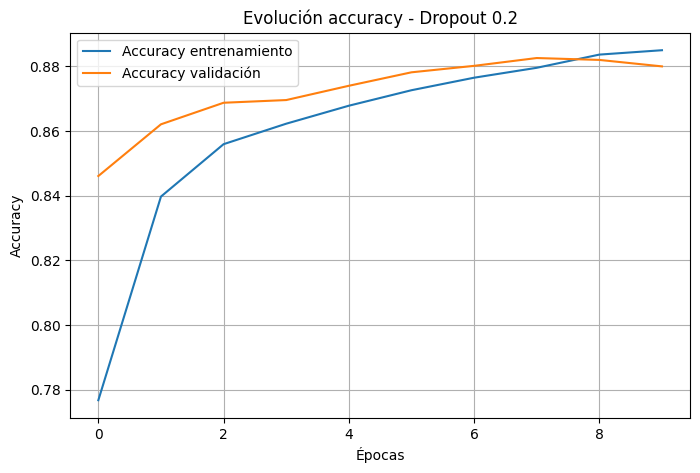

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout_02.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_dropout_02.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Dropout 0.2')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite analizar cómo cambia la pérdida durante el entrenamiento y la validación.  
Es útil para identificar si el modelo mantiene un comportamiento estable al aplicar Dropout.

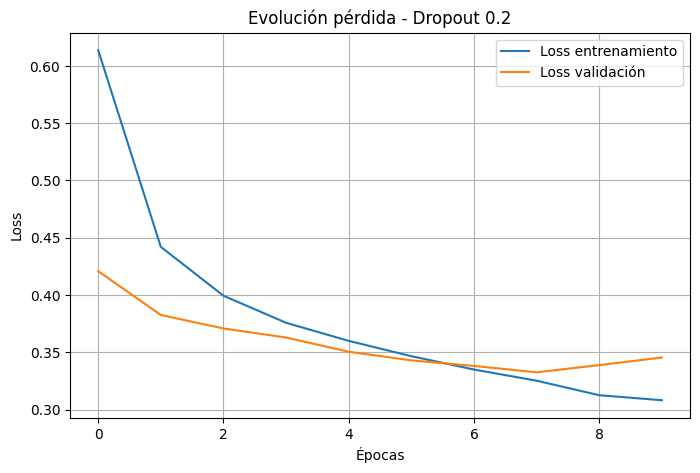

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout_02.history['loss'], label='Loss entrenamiento')
plt.plot(history_dropout_02.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Dropout 0.2')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Dropout 0.2

El modelo con Dropout 0.2 obtuvo un accuracy de 0.8692 y un F1-score de 0.8694, resultados cercanos al baseline. Esto indica que aplicar una tasa baja de Dropout permitió regularizar el modelo sin afectar demasiado su rendimiento.

En las curvas se observa que la accuracy de entrenamiento y validación se mantienen bastante cercanas, mientras que la pérdida disminuye de forma progresiva. Esto sugiere que Dropout 0.2 ayudó a controlar el aprendizaje sin limitar demasiado la capacidad del modelo.

En conclusión, Dropout 0.2 fue una configuración equilibrada, ya que permitió regularizar el modelo manteniendo resultados similares al baseline.

## Dropout 0.5

En este experimento se aumentó la tasa de Dropout a 0.5, desactivando el 50% de las neuronas durante el entrenamiento.

El objetivo es analizar cómo una regularización más agresiva afecta el aprendizaje del modelo y si ayuda a reducir aún más el sobreajuste.

#### Definición del modelo con Dropout 0.5

Se mantiene la misma arquitectura base del MLP, pero se agregan capas Dropout después de las capas densas ocultas.  
En esta prueba se utiliza una tasa de 0.5 para observar el efecto de una regularización más agresiva.

In [ ]:
model_dropout_05 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

El modelo se compila con el optimizador Adam, la función de pérdida Sparse Categorical Crossentropy y accuracy como métrica principal.  
Se mantiene la misma configuración del baseline para que la comparación sea justa y el cambio principal sea la tasa de Dropout.

In [ ]:
model_dropout_05.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo

Se mantuvieron los mismos parámetros del baseline para comparar correctamente los resultados. La única modificación realizada fue el aumento de la tasa Dropout a 0.5.

In [ ]:
history_dropout_05 = model_dropout_05.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6923 - loss: 0.8487 - val_accuracy: 0.8297 - val_loss: 0.4923
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7884 - loss: 0.5963 - val_accuracy: 0.8420 - val_loss: 0.4484
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8115 - loss: 0.5421 - val_accuracy: 0.8461 - val_loss: 0.4213
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8183 - loss: 0.5146 - val_accuracy: 0.8556 - val_loss: 0.4054
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8265 - loss: 0.4987 - val_accuracy: 0.8551 - val_loss: 0.3918
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8327 - loss: 0.4785 - val_accuracy: 0.8616 - val_loss: 0.3925
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8329 - loss: 0.4687 - val_accuracy: 0.8603 - val_loss: 0.3797
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8386 - loss: 0.4579 - 

#### Evaluación general del modelo

Se evalúa el modelo con el conjunto de prueba para obtener la pérdida y accuracy general.  
Estos resultados permitirán comparar Dropout 0.5 con el baseline y con Dropout 0.2.

In [ ]:
test_loss_dropout_05, test_accuracy_dropout_05 = model_dropout_05.evaluate(X_test, y_test)

print("Loss Dropout 0.5:", test_loss_dropout_05)
print("Accuracy Dropout 0.5:", test_accuracy_dropout_05)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8606 - loss: 0.3902
Loss Dropout 0.5: 0.39015325903892517
Accuracy Dropout 0.5: 0.8605999946594238


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan precision, recall y F1-score para analizar el desempeño del modelo con mayor detalle.  
Estas métricas serán utilizadas posteriormente en la tabla comparativa final.

In [ ]:
y_pred_dropout_05 = model_dropout_05.predict(X_test)
y_pred_dropout_05 = np.argmax(y_pred_dropout_05, axis=1)

accuracy_dropout_05 = accuracy_score(y_test, y_pred_dropout_05)
precision_dropout_05 = precision_score(y_test, y_pred_dropout_05, average='weighted')
recall_dropout_05 = recall_score(y_test, y_pred_dropout_05, average='weighted')
f1_dropout_05 = f1_score(y_test, y_pred_dropout_05, average='weighted')

print("Accuracy:", accuracy_dropout_05)
print("Precision:", precision_dropout_05)
print("Recall:", recall_dropout_05)
print("F1-score:", f1_dropout_05)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8606
Precision: 0.8600467203084048
Recall: 0.8606
F1-score: 0.8593263008869484


#### Evolución de la accuracy

Este gráfico muestra cómo evoluciona la accuracy de entrenamiento y validación durante las épocas.  
Permite identificar si Dropout 0.5 ayuda a mantener un comportamiento estable o si dificulta el aprendizaje del modelo.

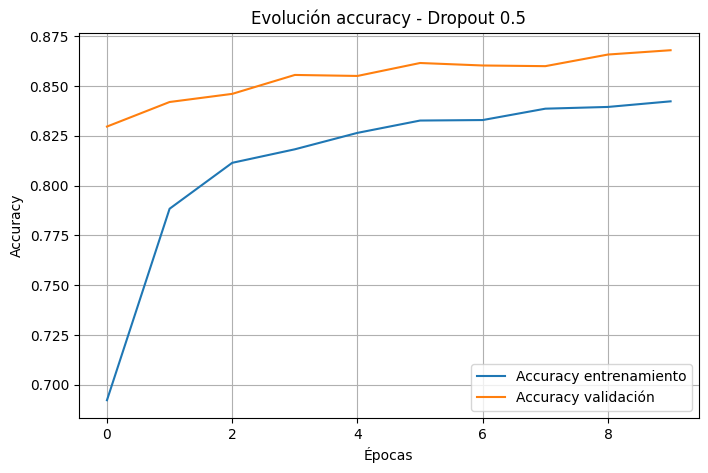

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout_05.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_dropout_05.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Dropout 0.5')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite observar cómo cambia la pérdida en entrenamiento y validación.  
Es útil para analizar si la regularización aplicada reduce el sobreajuste o si afecta negativamente el aprendizaje.

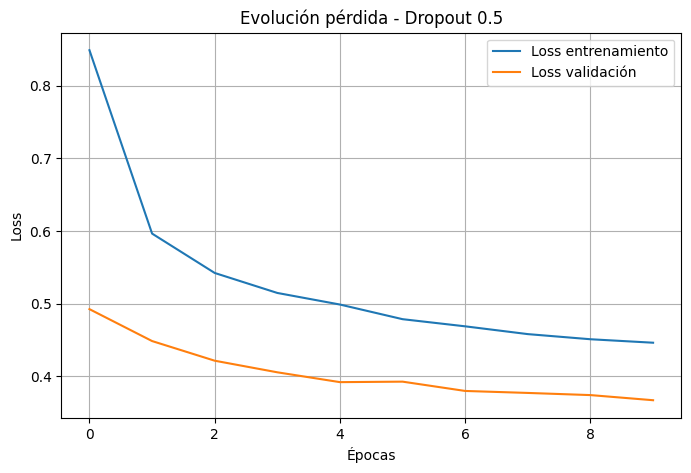

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout_05.history['loss'], label='Loss entrenamiento')
plt.plot(history_dropout_05.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Dropout 0.5')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Dropout 0.5

El modelo con Dropout 0.5 obtuvo un accuracy de 0.8606 y un F1-score de 0.8593, mostrando un rendimiento inferior en comparación con Dropout 0.2 y el modelo baseline.

En los gráficos se observa que las curvas de entrenamiento y validación se mantienen bastante cercanas, lo que indica que el sobreajuste se redujo considerablemente. Sin embargo, esto también sugiere que la regularización fue demasiado fuerte, dificultando que el modelo aprendiera correctamente todos los patrones del dataset.

La accuracy aumentó de manera más lenta y alcanzó valores menores, mientras que la pérdida se mantuvo más alta durante el entrenamiento. Esto puede deberse a que al desactivar el 50% de las neuronas, el modelo pierde demasiada información en cada época.

En conclusión, aunque Dropout 0.5 ayudó a controlar el sobreajuste, terminó limitando el aprendizaje del modelo y reduciendo su desempeño general.

## Batch Normalization

En este experimento se incorpora la técnica Batch Normalization dentro de la arquitectura del modelo.

Esta técnica permite normalizar las salidas de una capa antes de continuar el aprendizaje, ayudando a estabilizar el entrenamiento, acelerar la convergencia y reducir variaciones bruscas entre épocas.

#### Posición de Batch Normalization en la arquitectura

Batch Normalization fue incorporado después de cada capa Dense y antes de la función de activación Dropout.

Esta posición permite estabilizar los valores generados por las neuronas antes de aplicar regularización, ayudando a mantener un entrenamiento más estable y consistente.

In [ ]:
model_bn = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

Se utiliza nuevamente Adam como optimizador y Sparse Categorical Crossentropy como función de pérdida.

Se mantienen los mismos hiperparámetros del baseline para analizar específicamente el impacto de Batch Normalization.

In [ ]:
model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con Batch Normalization

El modelo se entrena durante 10 épocas utilizando batch size 32 y validation split de 0.2.

El objetivo es observar si Batch Normalization mejora la estabilidad del aprendizaje y reduce fluctuaciones entre entrenamiento y validación.

In [ ]:
history_bn = model_bn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8281 - loss: 0.4890 - val_accuracy: 0.8658 - val_loss: 0.3821
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8690 - loss: 0.3589 - val_accuracy: 0.8658 - val_loss: 0.3760
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8856 - loss: 0.3122 - val_accuracy: 0.8723 - val_loss: 0.3628
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8979 - loss: 0.2792 - val_accuracy: 0.8734 - val_loss: 0.3574
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9080 - loss: 0.2512 - val_accuracy: 0.8683 - val_loss: 0.3708
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9171 - loss: 0.2275 - val_accuracy: 0.8744 - val_loss: 0.3641
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9252 - loss: 0.2057 - val_accuracy: 0.8698 - val_loss: 0.3873
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9322 - loss: 0.1875 - 

#### Evaluación general del modelo

Se evalúa el desempeño general del modelo utilizando el conjunto de prueba para obtener loss y accuracy final.

In [ ]:
test_loss_bn, test_accuracy_bn = model_bn.evaluate(X_test, y_test)

print("Loss Batch Normalization:", test_loss_bn)
print("Accuracy Batch Normalization:", test_accuracy_bn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8555 - loss: 0.4931
Loss Batch Normalization: 0.4931269586086273
Accuracy Batch Normalization: 0.8554999828338623


#### Cálculo de métricas de clasificación

Se calculan accuracy, precision, recall y F1-score para comparar el comportamiento del modelo frente a las técnicas anteriores.

In [ ]:
y_pred_bn = model_bn.predict(X_test)
y_pred_bn = np.argmax(y_pred_bn, axis=1)

accuracy_bn = accuracy_score(y_test, y_pred_bn)
precision_bn = precision_score(y_test, y_pred_bn, average='weighted')
recall_bn = recall_score(y_test, y_pred_bn, average='weighted')
f1_bn = f1_score(y_test, y_pred_bn, average='weighted')

print("Accuracy:", accuracy_bn)
print("Precision:", precision_bn)
print("Recall:", recall_bn)
print("F1-score:", f1_bn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8555
Precision: 0.864485470252376
Recall: 0.8555
F1-score: 0.8559197049489486


#### Evolución de la accuracy

Este gráfico permite observar la estabilidad del aprendizaje durante las épocas y comparar el comportamiento entre entrenamiento y validación.

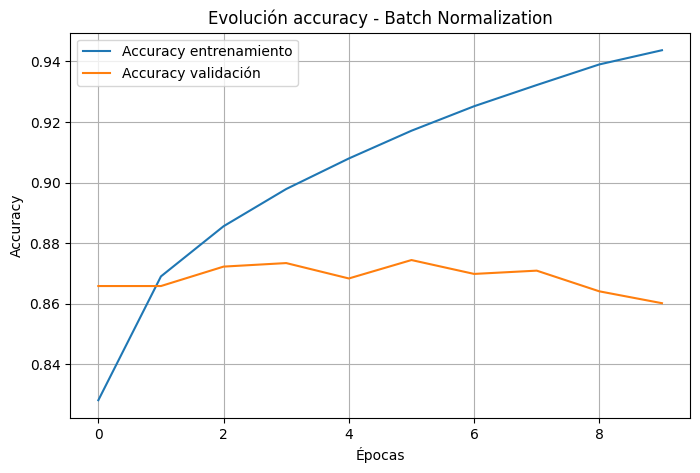

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_bn.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_bn.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Batch Normalization')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite analizar si Batch Normalization ayuda a mantener una disminución más estable de la pérdida durante el entrenamiento.

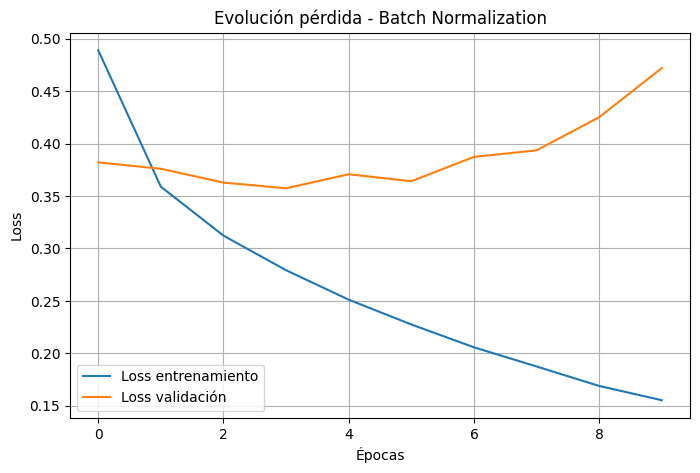

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_bn.history['loss'], label='Loss entrenamiento')
plt.plot(history_bn.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Batch Normalization')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Batch Normalization

Batch Normalization permitió que el modelo aprendiera rápidamente en entrenamiento, alcanzando una accuracy cercana al 94%. Sin embargo, la accuracy en test fue de 0.8555 y el F1-score de 0.8559, resultados inferiores al baseline.

En los gráficos se observa que la accuracy de entrenamiento sigue aumentando, mientras que la validación comienza a fluctuar y la pérdida de validación aumenta en las últimas épocas. Esto indica que, aunque Batch Normalization ayudó a estabilizar el flujo de aprendizaje dentro de la red, por sí sola no fue suficiente para mejorar la generalización del modelo.

En conclusión, Batch Normalization aportó estabilidad al entrenamiento, pero en este caso terminó mostrando señales de sobreajuste y no mejoró el rendimiento final.

## Early Stopping

Early Stopping es una técnica que detiene el entrenamiento cuando el modelo deja de mejorar en validación.  
Su objetivo es evitar que el modelo siga entrenando innecesariamente y comience a ajustarse demasiado a los datos de entrenamiento.

En esta sección se probarán dos valores de patience: 5 y 20, para analizar cómo cambia el comportamiento del modelo.

#### Definición del modelo para Early Stopping con patience=5

Se reconstruye el modelo baseline para aplicar Early Stopping sin modificar la arquitectura original.  
De esta manera, el cambio principal será la detención automática del entrenamiento según la pérdida de validación.

In [ ]:
model_es_5 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

Se utiliza la misma configuración del baseline: optimizador Adam, función de pérdida Sparse Categorical Crossentropy y accuracy como métrica principal.  
Esto permite comparar el efecto de Early Stopping sin cambiar otros parámetros.

In [ ]:
model_es_5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Configuración de Early Stopping

Se configura Early Stopping monitoreando `val_loss`, ya que esta métrica muestra cómo se comporta el modelo con datos de validación.  
Se utiliza `patience=5`, lo que significa que el entrenamiento se detendrá si la pérdida de validación no mejora durante 5 épocas consecutivas.  
Además, `restore_best_weights=True` permite recuperar los mejores pesos obtenidos durante el entrenamiento.

In [ ]:
early_stop_5 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#### Entrenamiento con Early Stopping patience=5

El modelo se entrena utilizando Early Stopping como callback.  
Para permitir que esta técnica actúe, se establece un número mayor de épocas, pero el entrenamiento puede detenerse antes si la validación deja de mejorar.

In [ ]:
history_es_5 = model_es_5.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_5]
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8174 - loss: 0.5135 - val_accuracy: 0.8518 - val_loss: 0.4114
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8629 - loss: 0.3771 - val_accuracy: 0.8646 - val_loss: 0.3703
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8762 - loss: 0.3385 - val_accuracy: 0.8717 - val_loss: 0.3524
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8844 - loss: 0.3134 - val_accuracy: 0.8739 - val_loss: 0.3463
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8905 - loss: 0.2942 - val_accuracy: 0.8723 - val_loss: 0.3552
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8969 - loss: 0.2777 - val_accuracy: 0.8752 - val_loss: 0.3509
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9024 - loss: 0.2636 - val_accuracy: 0.8762 - val_loss: 0.3605
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9069 - loss: 0.2515 - 

#### Resultado del entrenamiento con Early Stopping patience=5

El entrenamiento se detuvo en la época 9, antes de completar las 50 épocas definidas inicialmente. Esto indica que la pérdida de validación dejó de mejorar durante 5 épocas consecutivas, por lo que Early Stopping detuvo el proceso automáticamente.

Este comportamiento es positivo, ya que evita que el modelo siga entrenando de forma innecesaria y reduce el riesgo de sobreajuste. Además, al usar `restore_best_weights=True`, el modelo recupera los mejores pesos obtenidos durante el entrenamiento.

#### Evaluación general del modelo con Early Stopping patience=5

Se evalúa el modelo sobre el conjunto de prueba para analizar su desempeño después de aplicar Early Stopping.

In [ ]:
test_loss_es_5, test_accuracy_es_5 = model_es_5.evaluate(X_test, y_test)

print("Loss Early Stopping p=5:", test_loss_es_5)
print("Accuracy Early Stopping p=5:", test_accuracy_es_5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8671 - loss: 0.3662
Loss Early Stopping p=5: 0.36619508266448975
Accuracy Early Stopping p=5: 0.8671000003814697


#### Cálculo de métricas de clasificación

Se calculan accuracy, precision, recall y F1-score para comparar el modelo con Early Stopping frente al baseline y las demás técnicas de regularización.

In [ ]:
y_pred_es_5 = model_es_5.predict(X_test)
y_pred_es_5 = np.argmax(y_pred_es_5, axis=1)

accuracy_es_5 = accuracy_score(y_test, y_pred_es_5)
precision_es_5 = precision_score(y_test, y_pred_es_5, average='weighted')
recall_es_5 = recall_score(y_test, y_pred_es_5, average='weighted')
f1_es_5 = f1_score(y_test, y_pred_es_5, average='weighted')

print("Accuracy:", accuracy_es_5)
print("Precision:", precision_es_5)
print("Recall:", recall_es_5)
print("F1-score:", f1_es_5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy: 0.8671
Precision: 0.8718419955952279
Recall: 0.8671
F1-score: 0.8678544471265035


#### Evolución de la accuracy

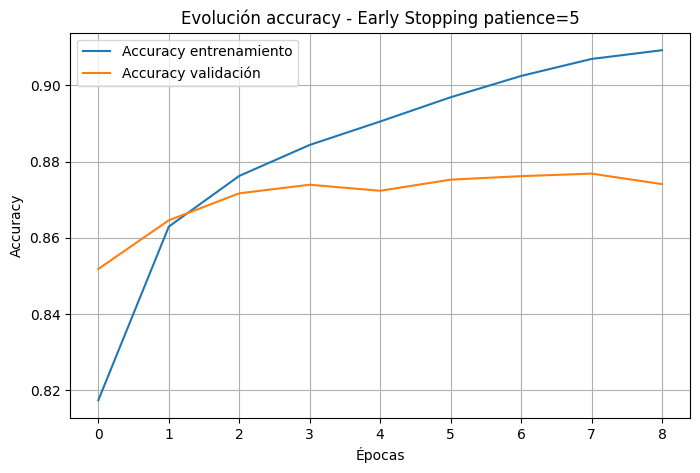

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_es_5.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_es_5.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Early Stopping patience=5')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

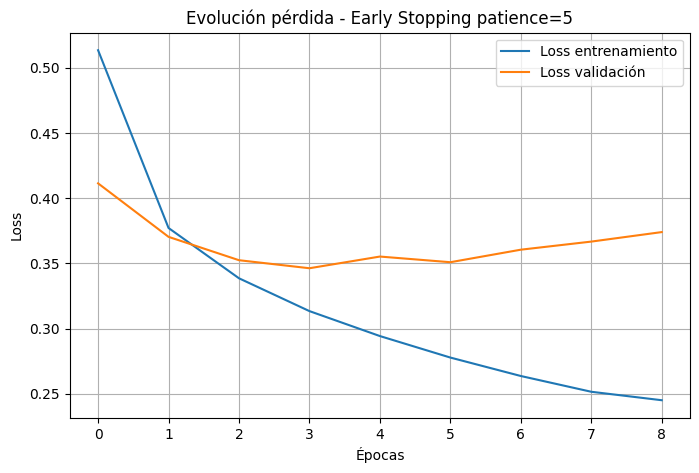

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_es_5.history['loss'], label='Loss entrenamiento')
plt.plot(history_es_5.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Early Stopping patience=5')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Early Stopping patience=5

El modelo con Early Stopping patience=5 se detuvo en la época 9, antes de completar las 50 épocas definidas. Esto indica que la pérdida de validación dejó de mejorar y el entrenamiento se detuvo automáticamente.

Obtuvo un accuracy de 0.8671 y un F1-score de 0.8679. Aunque no superó al baseline, permitió controlar el entrenamiento y evitar que el modelo siguiera ajustándose demasiado a los datos de entrenamiento.

En conclusión, Early Stopping con patience=5 ayudó a detener el entrenamiento a tiempo, pero en esta ejecución no fue la configuración con mejor rendimiento final.

## Early Stopping con patience=20

En esta segunda prueba se utiliza Early Stopping con patience=20. Esto significa que el modelo esperará hasta 20 épocas sin mejora en la pérdida de validación antes de detener el entrenamiento.

El objetivo es comparar si una paciencia mayor permite que el modelo siga aprendiendo por más tiempo o si aumenta el riesgo de sobreajuste.

#### Definición del modelo para Early Stopping con patience=20

Se reconstruye nuevamente el modelo baseline para realizar una comparación justa. La arquitectura se mantiene igual que en la EP1, y el cambio principal corresponde al valor de patience utilizado en Early Stopping.

In [ ]:
model_es_20 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

Se compila el modelo utilizando Adam, Sparse Categorical Crossentropy y accuracy, manteniendo la misma configuración del baseline. Esto permite comparar el efecto de Early Stopping con patience=20 sin modificar otros parámetros del modelo.

In [ ]:
model_es_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Configuración de Early Stopping

Se configura Early Stopping monitoreando `val_loss`, ya que esta métrica permite observar si el modelo mejora o empeora en datos de validación.  
En esta prueba se utiliza `patience=20`, por lo que el entrenamiento se detendrá solo si la pérdida de validación no mejora durante 20 épocas consecutivas. También se mantiene `restore_best_weights=True` para recuperar los mejores pesos.

In [ ]:
early_stop_20 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

#### Entrenamiento con Early Stopping patience=20

El modelo se entrena con un máximo de 50 épocas, batch size 32 y validation split de 0.2. Al utilizar una paciencia mayor, el modelo tendrá más tiempo para seguir entrenando antes de detenerse automáticamente.

In [ ]:
history_es_20 = model_es_20.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_20]
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8194 - loss: 0.5099 - val_accuracy: 0.8526 - val_loss: 0.4068
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8643 - loss: 0.3732 - val_accuracy: 0.8671 - val_loss: 0.3685
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8767 - loss: 0.3360 - val_accuracy: 0.8732 - val_loss: 0.3505
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8854 - loss: 0.3102 - val_accuracy: 0.8730 - val_loss: 0.3539
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8916 - loss: 0.2907 - val_accuracy: 0.8740 - val_loss: 0.3509
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8965 - loss: 0.2745 - val_accuracy: 0.8787 - val_loss: 0.3394
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9013 - loss: 0.2622 - val_accuracy: 0.8793 - val_loss: 0.3401
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9063 - loss: 0.2481 -

#### Resultado del entrenamiento con Early Stopping patience=20

Con patience=20, el modelo se detuvo en la época 26, entrenando por más tiempo que con patience=5. Esto ocurre porque Early Stopping espera más épocas antes de detener el proceso cuando la pérdida de validación deja de mejorar.

Esta configuración permitió que el modelo siguiera aprendiendo en entrenamiento, pero también aumentó el riesgo de sobreajuste, ya que la pérdida de validación comenzó a subir en las últimas épocas.

#### Evaluación general del modelo con Early Stopping patience=20

Se evalúa el modelo sobre el conjunto de prueba para comparar su rendimiento frente al modelo con patience=5 y las demás técnicas de regularización.

In [ ]:
test_loss_es_20, test_accuracy_es_20 = model_es_20.evaluate(X_test, y_test)

print("Loss Early Stopping p=20:", test_loss_es_20)
print("Accuracy Early Stopping p=20:", test_accuracy_es_20)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8686 - loss: 0.3667
Loss Early Stopping p=20: 0.3666541278362274
Accuracy Early Stopping p=20: 0.8686000108718872


#### Cálculo de métricas de clasificación

Se calculan accuracy, precision, recall y F1-score para analizar el desempeño del modelo con Early Stopping patience=20 y agregarlo posteriormente a la tabla comparativa final.

In [ ]:
y_pred_es_20 = model_es_20.predict(X_test)
y_pred_es_20 = np.argmax(y_pred_es_20, axis=1)

accuracy_es_20 = accuracy_score(y_test, y_pred_es_20)
precision_es_20 = precision_score(y_test, y_pred_es_20, average='weighted')
recall_es_20 = recall_score(y_test, y_pred_es_20, average='weighted')
f1_es_20 = f1_score(y_test, y_pred_es_20, average='weighted')

print("Accuracy:", accuracy_es_20)
print("Precision:", precision_es_20)
print("Recall:", recall_es_20)
print("F1-score:", f1_es_20)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8686
Precision: 0.8720884521383702
Recall: 0.8686
F1-score: 0.8689934334739088


#### Evolución de la accuracy

Este gráfico permite observar cómo evolucionó la accuracy durante un entrenamiento más largo. Sirve para analizar si una mayor paciencia mejora el rendimiento o si el modelo comienza a sobreajustarse.

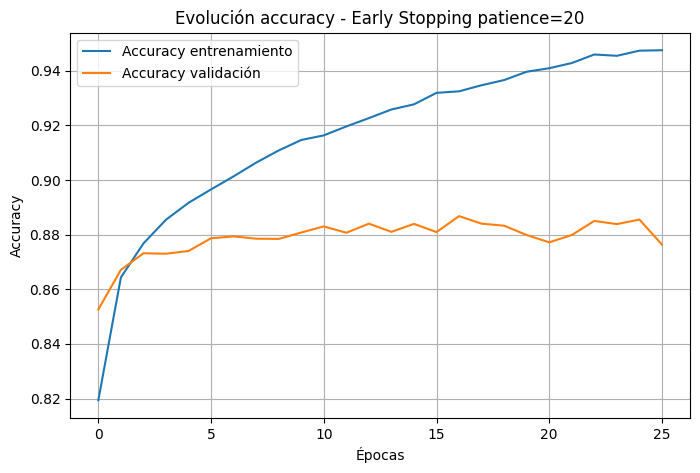

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_es_20.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_es_20.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Early Stopping patience=20')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite observar si la pérdida de validación mejora con más épocas o si comienza a fluctuar, lo que puede indicar que el modelo ya no está generalizando mejor.

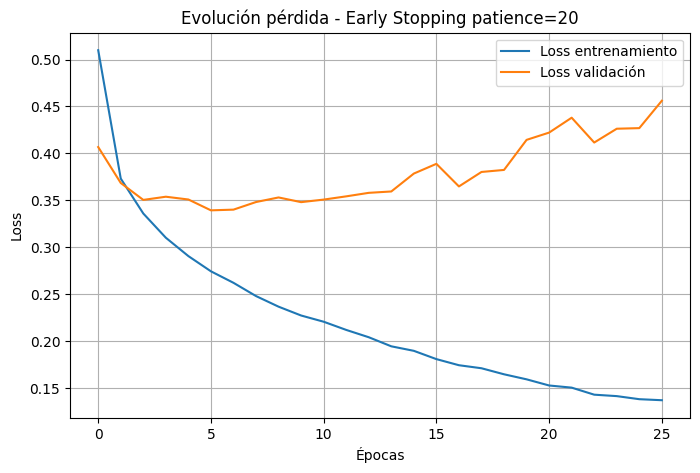

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_es_20.history['loss'], label='Loss entrenamiento')
plt.plot(history_es_20.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Early Stopping patience=20')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados Early Stopping patience=20

Con patience=20, el modelo entrenó durante más épocas, alcanzando una accuracy alta en entrenamiento. Sin embargo, la validación presentó fluctuaciones y la pérdida de validación comenzó a aumentar después de varias épocas.

El modelo obtuvo un accuracy de 0.8686 y un F1-score de 0.8690, resultados levemente superiores a patience=5, pero aún inferiores al baseline. Esto muestra que una paciencia mayor permitió entrenar más tiempo, aunque también aumentó el riesgo de sobreajuste.

En conclusión, patience=20 obtuvo métricas ligeramente mejores que patience=5, pero con un comportamiento menos controlado en las curvas de validación.

## Modelo final regularizado

En esta sección se construye un modelo final combinando las técnicas que presentaron mejor comportamiento durante los experimentos anteriores.

Se utiliza Batch Normalization para estabilizar el entrenamiento, Dropout 0.2 para reducir el riesgo de sobreajuste y Early Stopping con patience=5 para detener el entrenamiento cuando la validación deja de mejorar.

No se incorpora L2 ni Dropout 0.5, ya que en las pruebas anteriores estas configuraciones redujeron el rendimiento general del modelo.

#### Definición de la arquitectura final

El modelo final mantiene la estructura base del MLP, pero incorpora Batch Normalization después de cada capa densa, activación ReLU y Dropout 0.2 como técnica de regularización.

Esta combinación busca lograr un equilibrio entre aprendizaje, estabilidad y generalización.

In [ ]:
model_final = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo final

El modelo se compila utilizando Adam, Sparse Categorical Crossentropy y accuracy como métrica principal.

Se mantiene esta configuración para comparar el modelo final con los experimentos anteriores bajo las mismas condiciones.

In [ ]:
model_final.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Configuración de Early Stopping

Se utiliza Early Stopping con patience=5, ya que en la prueba anterior permitió detener el entrenamiento a tiempo y conservar un buen rendimiento en validación.

Además, se mantiene `restore_best_weights=True` para recuperar los mejores pesos obtenidos durante el entrenamiento.

In [ ]:
early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#### Entrenamiento del modelo final

El modelo final se entrena con un máximo de 50 épocas, batch size 32 y validation_split de 0.2.

Early Stopping permitirá detener el entrenamiento automáticamente si la pérdida de validación deja de mejorar, evitando entrenar innecesariamente.

In [ ]:
history_final = model_final.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_final]
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7972 - loss: 0.5848 - val_accuracy: 0.8442 - val_loss: 0.4317
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8400 - loss: 0.4431 - val_accuracy: 0.8588 - val_loss: 0.3887
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8537 - loss: 0.4002 - val_accuracy: 0.8661 - val_loss: 0.3677
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8637 - loss: 0.3733 - val_accuracy: 0.8662 - val_loss: 0.3621
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8719 - loss: 0.3522 - val_accuracy: 0.8724 - val_loss: 0.3523
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8776 - loss: 0.3366 - val_accuracy: 0.8749 - val_loss: 0.3442
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8802 - loss: 0.3232 - val_accuracy: 0.8595 - val_loss: 0.3817
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8856 - loss: 0.3086 - 

#### Resultado del entrenamiento del modelo final

El modelo final se detuvo en la época 18 debido a Early Stopping con patience=5. Esto indica que, después de varias épocas sin una mejora clara en la pérdida de validación, el entrenamiento fue detenido automáticamente.

El mejor comportamiento se observó cerca de la época 13, donde la validación alcanzó una accuracy de 0.8848 y una pérdida de 0.3270. Luego de esa época, el modelo siguió mejorando en entrenamiento, pero la validación comenzó a variar, lo que podía indicar un inicio de sobreajuste.

Por este motivo, Early Stopping ayudó a evitar que el modelo siguiera entrenando innecesariamente y permitió conservar los mejores pesos obtenidos durante el proceso.

#### Evaluación general del modelo final

Se evalúa el modelo final sobre el conjunto de prueba para conocer su rendimiento con datos no vistos.  
Este modelo combina Batch Normalization, Dropout 0.2 y Early Stopping con patience=5, por lo que sus resultados serán comparados con el baseline y las demás técnicas aplicadas.

In [ ]:
test_loss_final, test_accuracy_final = model_final.evaluate(X_test, y_test)

print("Loss modelo final:", test_loss_final)
print("Accuracy modelo final:", test_accuracy_final)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8776 - loss: 0.3492
Loss modelo final: 0.34923768043518066
Accuracy modelo final: 0.8776000142097473


#### Cálculo de métricas del modelo final

Además del accuracy, se calculan precision, recall y F1-score para obtener una evaluación más completa del modelo final.  
Estas métricas permiten analizar si la configuración regularizada mantiene un desempeño equilibrado en la clasificación.

In [ ]:
y_pred_final = model_final.predict(X_test)
y_pred_final = np.argmax(y_pred_final, axis=1)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print("Accuracy:", accuracy_final)
print("Precision:", precision_final)
print("Recall:", recall_final)
print("F1-score:", f1_final)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8776
Precision: 0.8776090761678286
Recall: 0.8776
F1-score: 0.8773090092207142


#### Análisis de resultados del modelo final regularizado

El modelo final regularizado obtuvo un accuracy de 0.8776, una precision de 0.8776, un recall de 0.8776 y un F1-score de 0.8773, mostrando un desempeño equilibrado en el conjunto de prueba.

La combinación de Batch Normalization, Dropout 0.2 y Early Stopping permitió controlar mejor el entrenamiento sin reducir de forma importante el rendimiento del modelo. Además, Early Stopping ayudó a detener el proceso cuando la validación dejó de mejorar, evitando un entrenamiento innecesario.

En comparación con otras configuraciones, el modelo final logró un buen equilibrio entre aprendizaje y generalización. Aunque no supera ampliamente al mejor resultado individual, mantiene métricas sólidas y reduce el riesgo de sobreajuste.

#### Evolución de la accuracy del modelo final

Este gráfico muestra cómo evolucionó la accuracy del modelo final durante el entrenamiento, comparando el comportamiento en entrenamiento y validación.

Esto permite observar si la combinación de Batch Normalization, Dropout 0.2 y Early Stopping mantuvo un aprendizaje estable y si el modelo logró generalizar correctamente.

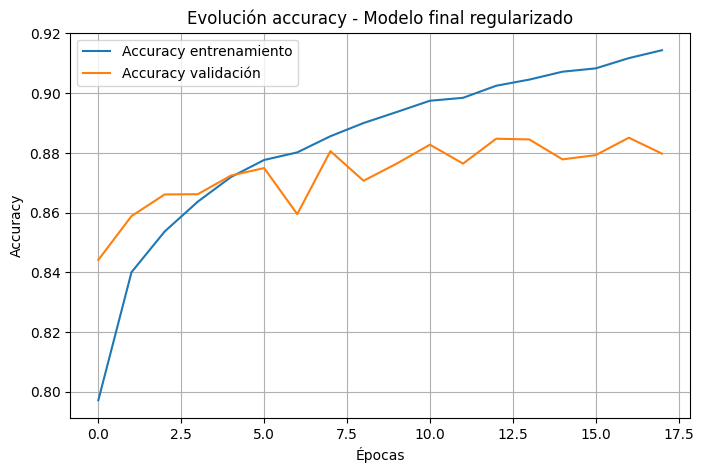

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_final.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_final.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - Modelo final regularizado')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)
plt.show()

### Evolución de la pérdida del modelo final

Este gráfico permite analizar cómo cambió la pérdida durante el entrenamiento y la validación.

Es importante observar si la pérdida de validación se mantiene estable o si comienza a aumentar, ya que esto puede indicar señales de sobreajuste.

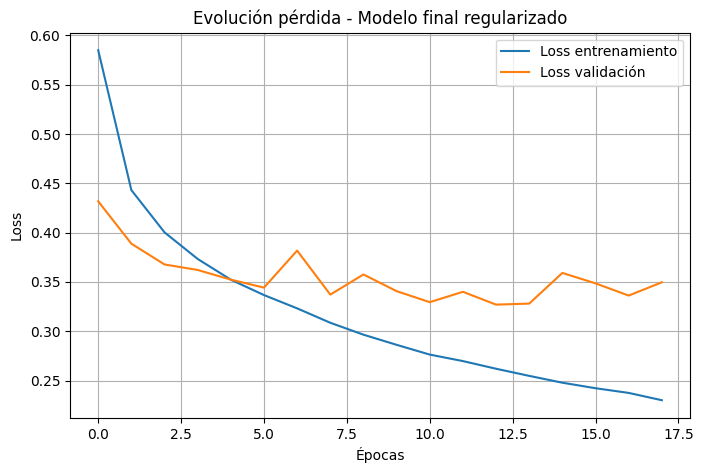

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_final.history['loss'], label='Loss entrenamiento')
plt.plot(history_final.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - Modelo final regularizado')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()

### Análisis final del modelo regularizado

El modelo final regularizado obtuvo un accuracy de 0.8776, una precision de 0.8776, un recall de 0.8776 y un F1-score de 0.8773, mostrando un desempeño equilibrado en el conjunto de prueba.

En el gráfico de accuracy se observa que el modelo mejora progresivamente durante el entrenamiento, mientras que la validación se mantiene cercana al 89%. Esto indica que el modelo logró aprender patrones importantes sin perder completamente su capacidad de generalización.

En el gráfico de pérdida, la pérdida de entrenamiento disminuye de forma constante, mientras que la pérdida de validación baja al inicio, pero luego presenta algunas variaciones. Esto muestra que el modelo comenzaba a acercarse a un posible sobreajuste en las últimas épocas.

En este caso, Early Stopping fue importante porque detuvo el entrenamiento cuando la validación dejó de mejorar de forma clara. En conclusión, la combinación de Batch Normalization, Dropout 0.2 y Early Stopping permitió obtener un modelo estable, con buen rendimiento y menor riesgo de sobreentrenamiento.

## Tabla comparativa final de métricas

En esta sección se presenta una tabla comparativa con los resultados obtenidos por cada modelo evaluado.  
Se incluyen las métricas accuracy, precision, recall y F1-score, ya que permiten comparar el rendimiento general de cada configuración y analizar cuál obtuvo el mejor equilibrio entre aprendizaje y generalización.

In [ ]:
resultados = pd.DataFrame({
    'Modelo': [
        'Baseline EP1',
        'L2 0.001',
        'L2 0.01',
        'Dropout 0.2',
        'Dropout 0.5',
        'Batch Normalization',
        'Early Stopping p=5',
        'Early Stopping p=20',
        'Modelo final regularizado'
    ],
    'Accuracy': [
        accuracy,
        accuracy_l2_001,
        accuracy_l2_01,
        accuracy_dropout_02,
        accuracy_dropout_05,
        accuracy_bn,
        accuracy_es_5,
        accuracy_es_20,
        accuracy_final
    ],
    'Precision': [
        precision,
        precision_l2_001,
        precision_l2_01,
        precision_dropout_02,
        precision_dropout_05,
        precision_bn,
        precision_es_5,
        precision_es_20,
        precision_final
    ],
    'Recall': [
        recall,
        recall_l2_001,
        recall_l2_01,
        recall_dropout_02,
        recall_dropout_05,
        recall_bn,
        recall_es_5,
        recall_es_20,
        recall_final
    ],
    'F1-score': [
        f1,
        f1_l2_001,
        f1_l2_01,
        f1_dropout_02,
        f1_dropout_05,
        f1_bn,
        f1_es_5,
        f1_es_20,
        f1_final
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Baseline EP1,0.8741,0.875259,0.8741,0.873886
1,L2 0.001,0.8587,0.864640,0.8587,0.859089
2,L2 0.01,0.8291,0.834178,0.8291,0.828848
3,Dropout 0.2,0.8692,0.871761,0.8692,0.869406
4,Dropout 0.5,0.8606,0.860047,0.8606,0.859326
5,Batch Normalization,0.8555,0.864485,0.8555,0.855920
6,Early Stopping p=5,0.8671,0.871842,0.8671,0.867854
7,Early Stopping p=20,0.8686,0.872088,0.8686,0.868993
8,Modelo final regularizado,0.8776,0.877609,0.8776,0.877309


#### Análisis de la tabla comparativa

La tabla muestra que el modelo final regularizado obtuvo el mejor desempeño general, con un accuracy de 0.8776 y un F1-score de 0.8773. Esto indica que la combinación de Batch Normalization, Dropout 0.2 y Early Stopping logró un leve mejor rendimiento que el baseline.

También se observa que L2, especialmente con λ = 0.01, redujo considerablemente el rendimiento del modelo, probablemente porque la regularización fue demasiado fuerte y limitó su capacidad de aprendizaje. Algo similar ocurrió con Dropout 0.5, que bajó las métricas en comparación con Dropout 0.2.

Por otro lado, Early Stopping con patience=20 obtuvo métricas levemente superiores a patience=5, aunque con mayor riesgo de sobreajuste por entrenar durante más épocas. En general, los resultados muestran que no todas las técnicas mejoran el modelo por sí solas, sino que deben probarse y compararse para elegir la mejor configuración.

## Gráficos comparativos finales

En esta sección se presentan gráficos comparativos para visualizar el rendimiento de todos los modelos evaluados.  
Estos gráficos permiten identificar de forma más clara qué configuración obtuvo mejores resultados y cómo impactaron las técnicas de regularización.

#### Comparación de Accuracy por modelo

El siguiente gráfico compara el accuracy obtenido por cada configuración evaluada. Esta métrica permite observar qué modelo tuvo mayor porcentaje de aciertos sobre el conjunto de prueba.

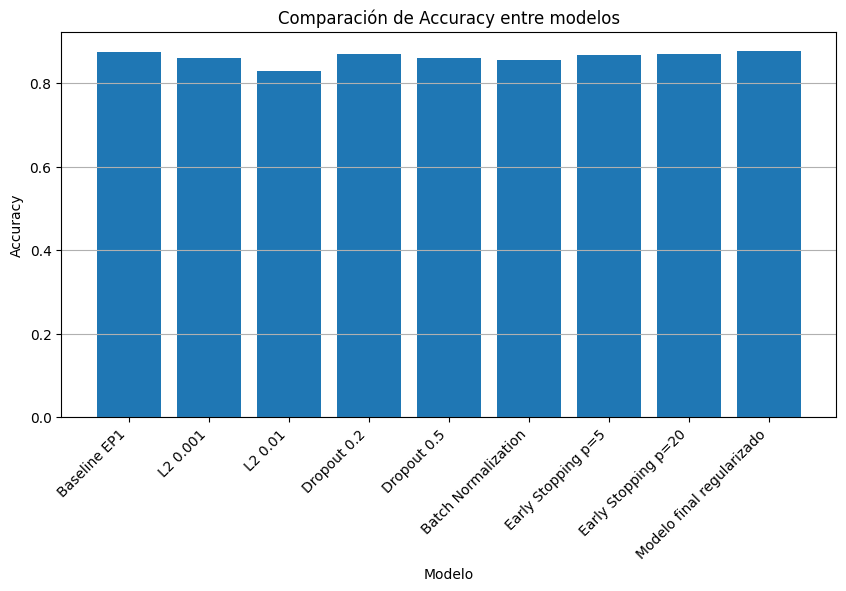

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(resultados['Modelo'], resultados['Accuracy'])

plt.title('Comparación de Accuracy entre modelos')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

#### Comparación de F1-score por modelo

El siguiente gráfico compara el F1-score de cada modelo.  
Esta métrica es importante porque resume el equilibrio entre precision y recall, entregando una visión más completa del rendimiento del clasificador.

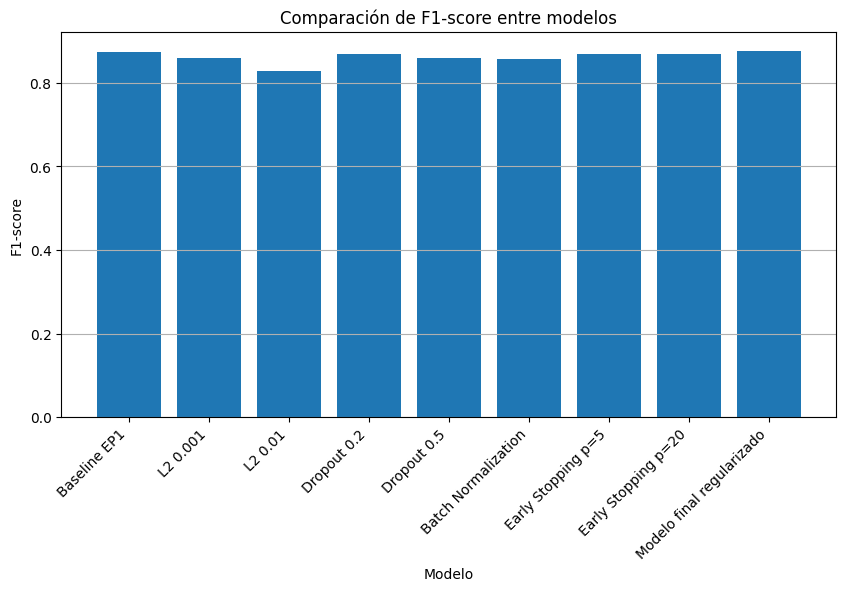

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(resultados['Modelo'], resultados['F1-score'])

plt.title('Comparación de F1-score entre modelos')
plt.xlabel('Modelo')
plt.ylabel('F1-score')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

#### Análisis de los gráficos comparativos finales

Los gráficos comparativos muestran que el modelo final regularizado obtuvo uno de los mejores resultados generales, destacando tanto en accuracy como en F1-score. Esto indica que la combinación de Batch Normalization, Dropout 0.2 y Early Stopping permitió mantener un buen equilibrio entre rendimiento y generalización.

También se observa que el baseline tuvo un rendimiento competitivo, lo que indica que el modelo original ya presentaba un desempeño estable. En cambio, L2 con λ = 0.01 presentó los resultados más bajos, lo que sugiere que una regularización demasiado fuerte puede limitar el aprendizaje del modelo.

En general, los gráficos permiten concluir que las técnicas de regularización no siempre mejoran el modelo por separado, pero al combinarlas correctamente pueden ayudar a obtener un comportamiento más estable y controlado.

## Conclusiones finales

En esta Evaluación Parcial 2 se continuó el trabajo de la EP1, utilizando el modelo MLP baseline como referencia para analizar el impacto de distintas técnicas de regularización sobre el rendimiento y la generalización del modelo.

Los resultados mostraron que no todas las técnicas mejoran automáticamente el desempeño. L2, especialmente con λ = 0.01, redujo las métricas del modelo, probablemente porque la penalización fue demasiado fuerte. Algo similar ocurrió con Dropout 0.5, ya que al desactivar muchas neuronas se limitó la capacidad de aprendizaje.

En cambio, Dropout 0.2 presentó un comportamiento más equilibrado, Batch Normalization ayudó a estabilizar el entrenamiento y Early Stopping con patience=5 permitió detener el proceso a tiempo, evitando entrenamiento innecesario y reduciendo el riesgo de sobreajuste.

El modelo final regularizado combinó Batch Normalization, Dropout 0.2 y Early Stopping con patience=5, obteniendo un accuracy de 0.8776 y un F1-score de 0.8773. Aunque la mejora frente al baseline no fue muy alta, el modelo final mostró un comportamiento más estable y controlado.

En conclusión, la regularización permitió comprobar que mejorar un modelo no depende solo de agregar técnicas, sino de elegir correctamente sus valores y combinaciones. Como mejora futura, se podría probar una arquitectura CNN, ya que al trabajar con imágenes podría capturar mejor patrones como bordes, formas y texturas.